In [5]:
import sys
print(sys.executable)

c:\Users\arron\anaconda3\python.exe


In [6]:
import sys
!{sys.executable} -m pip install xgboost

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

In [8]:
df = pd.read_csv('sample_sales.csv')
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Product,Sales
0,2025-01-01,A,120
1,2025-01-02,A,130
2,2025-01-03,A,125
3,2025-01-04,A,140
4,2025-01-05,A,150


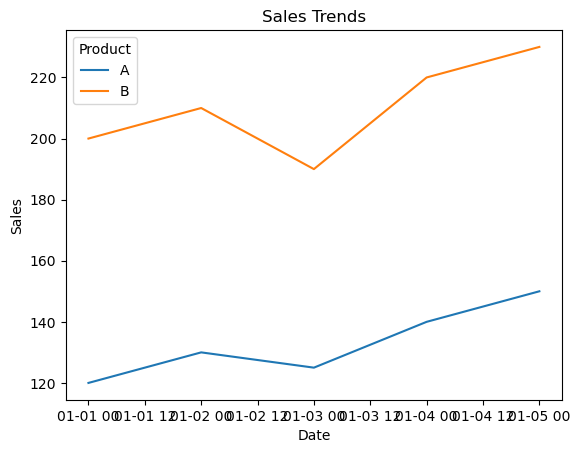

In [9]:
sns.lineplot(x='Date', y='Sales', hue='Product', data=df)
plt.title("Sales Trends")
plt.show()

In [10]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek

df = pd.get_dummies(df, columns=['Product'])

In [11]:
train = df[df['Date'] < '2025-01-04']
test = df[df['Date'] >= '2025-01-04']

X_train = train.drop(['Sales', 'Date'], axis=1)
y_train = train['Sales']

X_test = test.drop(['Sales', 'Date'], axis=1)
y_test = test['Sales']

model = XGBRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

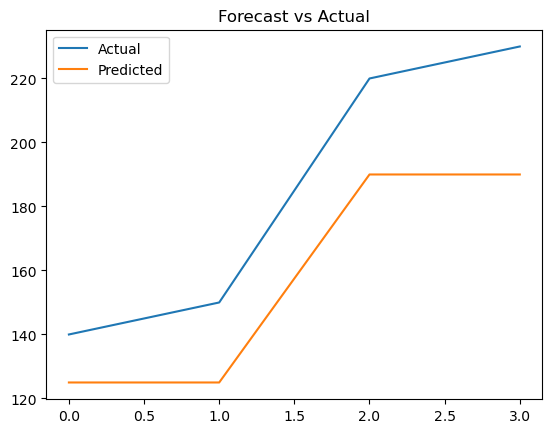

In [12]:
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [13]:
print("Insights:")
print("- Sales show upward trend over time")
print("- Product B has higher demand than A")
print("- Model captures trend reasonably well")

Insights:
- Sales show upward trend over time
- Product B has higher demand than A
- Model captures trend reasonably well
